<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/Hands_on_Activity_5_3_Bagging%2C_Boosting_and_Stacking_PART_II_(De_los_Reyes).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Boosting and Stacking Exercises

## Introduction

In this activity, I will be using the [Glass Identification ](https://archive.ics.uci.edu/dataset/42/glass+identification) dataset from  UCI which contains 10 attributes including id.

**Attributes information**


* Id number: 1 to 214 (removed from CSV file)
* RI: refractive index
* Na: Sodium (unit measurement: weight percent in corresponding oxide, as are attributes 4-10)
* Mg: Magnesium
* Al: Aluminum
* Si: Silicon
* K: Potassium
* Ca: Calcium
* Ba: Barium
* Fe: Iron
* Type of glass: (class attribute)
 1. building_windows_float_processed
 2. building_windows_non_float_processed
 3. vehicle_windows_float_processed
 4. vehicle_windows_non_float_processed (none in this database)
 5. containers
 6. tableware
 7. headlamps

In [ ]:
from __future__ import print_function
import os
data_path = ['..', '..', 'data']

## Import the Dataset

* Import the data from the file `glass.csv` and examine the shape and data types. For the data types, there will be too many to list each column separately. Rather, aggregate the types by count.

In [ ]:
import pandas as pd
import numpy as np

filepath = '/content/glass.csv'
data = pd.read_csv(filepath,sep =',')

The data has quite a few predictor columns.

In [ ]:
data.shape

(214, 10)

And they're all float values and one integer columns for our classification

In [ ]:
data.dtypes.value_counts()

,count
float64,9
int64,1


In [ ]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Train/Test Splitting


In [ ]:
data['Type'].value_counts()

,count
Type,
2,76
1,70
7,29
3,17
5,13
6,9


In [ ]:
from re import X
#train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop('Type', axis=1), data['Type'],
                 test_size=0.3, random_state=42)

In [ ]:
data.Type.unique()

array([1, 2, 3, 5, 6, 7])

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((149, 9), (149,), (65, 9), (65,))

## Boosting Model

* Fit gradient boosted tree models with all parameters set to their defaults the following tree numbers (`n_estimators = [25, 50, 100, 200, 400]`) and evaluate the accuracy on the test data for each of these models.
* Plot the accuracy as a function of estimator number.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

error_list = list()

# Iterate through all of the possibilities for number of estimators
tree_list = [15, 50, 100, 200, 400]
for n_trees in tree_list:

    # Initialize the gradient boost classifier
    GBC = GradientBoostingClassifier(n_estimators=n_trees,
                                     subsample=0.5,
                                     max_features=4,
                                     random_state=42)

    # Fit the model
    GBC.fit(X_train.values, y_train.values)
    y_pred = GBC.predict(X_test)

    # Get the error
    error = 1. - accuracy_score(y_test, y_pred)

    # Store it
    error_list.append(pd.Series({'n_trees': n_trees, 'error': error}))

error_df = pd.concat(error_list, axis=1).T.set_index('n_trees')

error_df

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


,error
n_trees,
15.0,0.307692
50.0,0.261538
100.0,0.246154
200.0,0.230769
400.0,0.184615


Now plot the result.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#% matplotlib inline

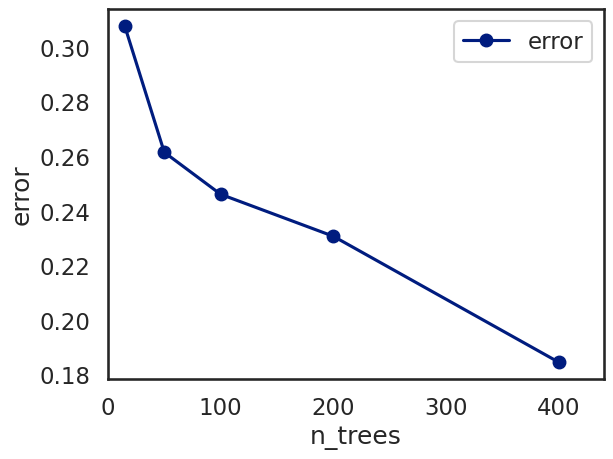

In [ ]:
sns.set_context('talk')
sns.set_style('white')
sns.set_palette('dark')

# Create the plot
ax = error_df.plot(marker='o')

# Set parameters
ax.set(xlabel='n_trees', ylabel='error')
ax.set_xlim(0, max(error_df.index)*1.1);

<font color= green> As we notice,the number of trees in the model increases, the error rate generally decreases. This is a typical behavior for ensemble methods.Thus we can say that more trees often lead to better predictions and lower error. While increasing the number of trees initially leads to significant error reduction, the improvement becomes less pronounced as the number of trees grows larger. We can also remember that overfitting may occur in the process.

## Hypertuning the GradientBoosting() model

* Using a grid search with cross-validation, fit a new gradient boosted classifier with the a list of estimators, similar to question 3. Also consider  varying the learning rates (0.1, 0.01, 0.001, etc.), the subsampling value (1.0 or 0.5), and the number of maximum features (1, 2, etc.).
* Examine the parameters of the best fit model.
* Calculate relevant error metrics on this model and examine the confusion matrix.


In [ ]:
from sklearn.model_selection import GridSearchCV

# The parameters to be fit--only n_estimators and learning rate
# have been varied here for simplicity
param_grid = {'n_estimators': [200, 400],
              'learning_rate': [0.1, 0.01]}

# The grid search object
GV_GBC = GridSearchCV(GradientBoostingClassifier(subsample=0.5,
                                                 max_features=4,
                                                 random_state=42),
                      param_grid=param_grid,
                      scoring='accuracy',
                      n_jobs=-1)

# Do the grid search
GV_GBC = GV_GBC.fit(X_train, y_train)

In [ ]:
# The best model
GV_GBC.best_estimator_

GradientBoostingClassifier(max_features=4, n_estimators=400, random_state=42,
                           subsample=0.5)

The error metrics. Classification report is particularly convenient for multi-class cases.

In [ ]:
from sklearn.metrics import classification_report

y_pred = GV_GBC.predict(X_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           1       0.95      0.75      0.84        24
           2       0.83      0.79      0.81        24
           3       0.25      1.00      0.40         1
           5       0.33      1.00      0.50         2
           6       1.00      0.75      0.86         4
           7       1.00      1.00      1.00        10

    accuracy                           0.82        65
   macro avg       0.73      0.88      0.73        65
weighted avg       0.88      0.82      0.84        65



In [ ]:
#accuracy score
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8153846153846154

The confusion matrix. Note that the gradient boosted model has a little trouble distinguishing between activity class 1 and 2.

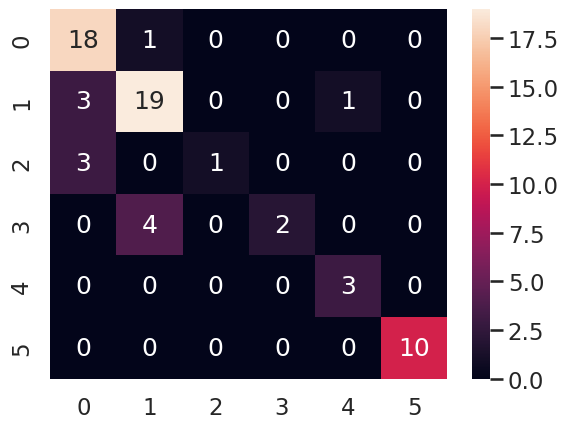

In [ ]:
from sklearn.metrics import confusion_matrix

sns.set_context('talk')
cm = confusion_matrix(y_test, y_pred)
ax = sns.heatmap(cm, annot=True, fmt='d')

In [ ]:
y_test.value_counts()

,count
Type,
2,23
1,19
7,10
5,6
3,4
6,3


Interpretation:
<font color=green> In our classification matrix we got a some misclassification in Type 1,2,3 and 5.We also got a 0.81 accuracy score which suggest that our model are slgihtly good in classifiying some  type of glass as evident  on the confusion matrix

## Question 5

* Create an AdaBoost model and fit it using grid search, much like question 4. Try a range of estimators between 100 and 200.
* Compare the errors from AdaBoost to those from the GradientBoostedClassifier.

**NOTE:** Setting `max_features=4` in the decision tree classifier used as the base classifier for AdaBoost will increase the convergence rate.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ABC = AdaBoostClassifier(DecisionTreeClassifier(max_features=4))

param_grid = {'n_estimators': [100, 150, 200,400],
              'learning_rate': [0.01, 0.001]}

GV_ABC = GridSearchCV(ABC,
                      param_grid=param_grid,
                      scoring='accuracy',
                      n_jobs=-1)

GV_ABC = GV_ABC.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


The best model.

In [ ]:
# The best model
GV_ABC.best_estimator_

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_features=4),
                   learning_rate=0.001, n_estimators=400)

The error metrics. Note that the issues with class 1 and 2 appear to have become more problematic and now include class 0. Also note other issues for classes 3 - 5. AdaBoost is very sensitive to outliers, so that could be the problem here.

In [ ]:
y_pred = GV_ABC.predict(X_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           1       0.84      0.64      0.73        25
           2       0.48      0.79      0.59        14
           3       0.25      0.25      0.25         4
           5       0.83      0.83      0.83         6
           6       1.00      0.75      0.86         4
           7       0.90      0.75      0.82        12

    accuracy                           0.69        65
   macro avg       0.72      0.67      0.68        65
weighted avg       0.75      0.69      0.70        65



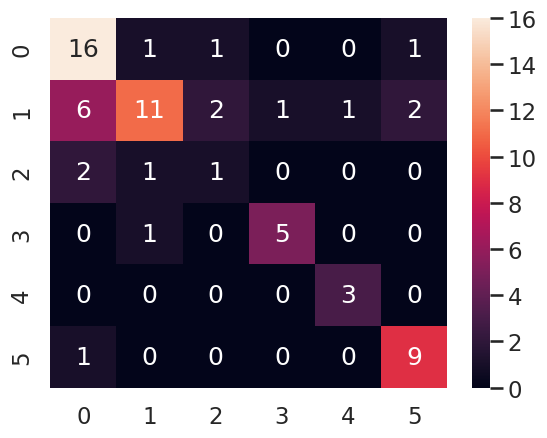

In [ ]:
sns.set_context('talk')
cm = confusion_matrix(y_test, y_pred)
ax = sns.heatmap(cm, annot=True, fmt='d')

Interpretation:
<font color = green> In using the AdaBoost classifier() we got a low accuracy having a percentage of 69% and also we can see that our precision and accuracy in each label decreases. Our model using  Adaboost give a low performance as we can see in the confusion matrix, our model has many misclassification in each label.

## Stacking model using votingClassifier

* Fit a logistic regression model with regularization. This can be a replica of a model that worked well in the exercises from week 4.
* Using `VotingClassifier`, fit the logistic regression model along with either the GratientBoostedClassifier or the AdaBoost model (or both) from questions 4 and 5.
* Determine the error as before and compare the results to the appropriate gradient boosted model(s).
* Plot the confusion matrix for the best model created in this set of exercises.

In [ ]:
from sklearn.linear_model import LogisticRegressionCV

# L2 regularized logistic regression
LR_L2 = LogisticRegressionCV(Cs=5, cv=4, penalty='l2').fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Check the errors and confusion matrix for the logistic regression model.

In [ ]:
y_pred = LR_L2.predict(X_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           1       0.74      0.70      0.72        20
           2       0.74      0.61      0.67        28
           3       0.00      0.00      0.00         0
           5       0.33      1.00      0.50         2
           6       1.00      0.75      0.86         4
           7       1.00      0.91      0.95        11

    accuracy                           0.71        65
   macro avg       0.63      0.66      0.62        65
weighted avg       0.79      0.71      0.74        65



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


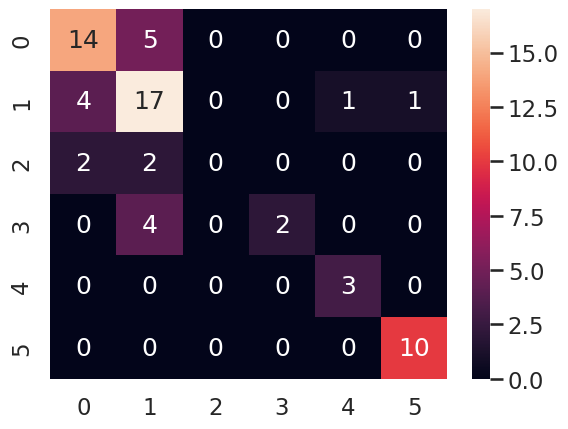

In [ ]:
sns.set_context('talk')
cm = confusion_matrix(y_test, y_pred)
ax = sns.heatmap(cm, annot=True, fmt='d')

And now the stacked model.

In [ ]:
from sklearn.ensemble import VotingClassifier

# The combined model--logistic regression and gradient boosted trees
estimators = [('LR_L2', LR_L2), ('GBC', GV_GBC)]

# Though it wasn't done here, it is often desirable to train
# this model using an additional hold-out data set and/or with cross validation
VC = VotingClassifier(estimators, voting='soft')
VC = VC.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Finally the error on the voting classifier. We do a little better here than with either logistic regression or gradient boosted trees alone. However, the fact that logistic regression does almost as well as gradient boosted trees is an important reminder that it's good practice to try the simplest model first. In some cases, its performance will be good enough.

In [ ]:
y_pred = VC.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.75      0.95      0.84        19
           2       0.79      0.83      0.81        23
           3       1.00      0.25      0.40         4
           5       1.00      0.33      0.50         6
           6       0.75      1.00      0.86         3
           7       1.00      1.00      1.00        10

    accuracy                           0.82        65
   macro avg       0.88      0.73      0.73        65
weighted avg       0.84      0.82      0.79        65



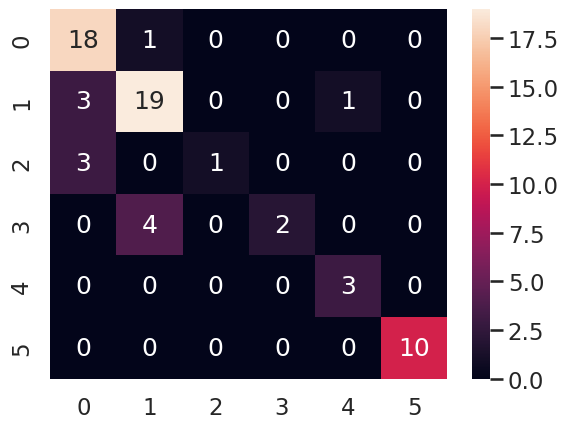

In [ ]:
sns.set_context('talk')
cm = confusion_matrix(y_test, y_pred)
ax = sns.heatmap(cm, annot=True, fmt='d')

<font color= 'green'> We use Voting classifier to perform stacking model. Upon performing the activity we got an accuracy of 0.82 which is close to the AdaboostClassfier(). In the confusion matrix we also have a lot of misclassification particularly in label 0 to 4 which suggest that our model has a difficulty in classifyin each label particularly in label 0 which a lot on misclassified are underlying.

#Conclusion

Using the `glass.csv` we perform various boosting and stacking model which gives a better results compare to the bagging as compare to the part one of this activity. Upon evaluating the performance in each model, we got  Adaboost classifier as the highest performing model  in all the model  we do. With an accuracy of 83% which is slightly better  compare to the result I've seen in the internet. I also got a problem in XGBoost Classifier particularly in scaling the model since  our label does not fit  to the models label that is why i dont include xgboost. Our model distribution may be one of the cause why our model dont perform well since our dataset is not evenly distributed. Throughout this activity, the Adaboost and the Stacking using  VotingClassifier are the highest performing model I get and in the future I could use other model to train this dataset for better result.